## Data Preprocessing & Feature Engineering

# 1. Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/heart2.csv")
print(df.shape)
df.head()

(920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


# 2. Missing Value Analysis


Check how much missing data we actually have per column before deciding how to handle it.

In [2]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalach      55
exang        55
chol         30
restecg       2
cp            0
sex           0
age           0
target        0
source        0
dtype: int64

## 3. Duplicate Removal

**Fix:** the result of `drop_duplicates()` must be assigned back to `df`, otherwise nothing changes.

In [3]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

df = df.drop_duplicates().reset_index(drop=True)   
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 2
Shape after removing duplicates: (918, 15)


## 4. Train-Test Split (done *before* imputation/scaling/outlier handling)

This is the key leakage fix. All preprocessing statistics (imputation values, outlier bounds, scaling
mean/std) must be learned **only** from the training data, then simply applied to the test data. If we
fit on the full dataset first (as the original notebook did), information from the test set leaks into
training and the reported test performance becomes overly optimistic.

We also drop the `source` column (which dataset each row came from — not a real clinical feature) before
splitting.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target", "source"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(734, 13) (184, 13)


## 5. Handle Outliers (IQR method) — fitted on train only


In [ ]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

iqr_bounds = {}

for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)  
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_bounds[col] = (lower, upper)

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)   

print(iqr_bounds)

{'age': (np.float64(27.5), np.float64(79.5)), 'trestbps': (np.float64(90.0), np.float64(170.0)), 'chol': (np.float64(31.5), np.float64(411.5)), 'thalach': (np.float64(64.5), np.float64(212.5)), 'oldpeak': (np.float64(-2.25), np.float64(3.75))}


In [6]:
X_train["chol"].describe()

count    709.000000
mean     204.973202
std       98.347074
min       31.500000
25%      174.000000
50%      223.000000
75%      269.000000
max      411.500000
Name: chol, dtype: float64

## 6. Missing Value Imputation + Feature Scaling
- Imputes **numeric** columns (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) with the **median**
  (robust to any remaining skew/outliers), then scales them with `StandardScaler`.
- Imputes **categorical/ordinal** columns (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`)
  with the **most frequent value**. These are category codes, so taking a mean (as the original notebook
  did, in the baseline-model notebook) would create meaningless in-between values — most-frequent is the
  correct strategy for categorical data.

The whole transformer is `fit()` on `X_train` only, then used to `.transform()` both `X_train` and
`X_test` — no leakage.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric_cols),
        ("cat", SimpleImputer(strategy="most_frequent"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)   # fit ONLY on training data
X_test_processed = preprocessor.transform(X_test)         # reuse training statistics

# Recover a clean column order/name list (ColumnTransformer reorders: num cols first, then cat cols)
processed_columns = numeric_cols + categorical_cols

X_train_df = pd.DataFrame(X_train_processed, columns=processed_columns)
X_test_df = pd.DataFrame(X_test_processed, columns=processed_columns)

print("Missing values left in X_train:", pd.DataFrame(X_train_processed).isnull().sum().sum())
print("Missing values left in X_test:", pd.DataFrame(X_test_processed).isnull().sum().sum())

Missing values left in X_train: 0
Missing values left in X_test: 0


## 7. Save the Processed Datasets

Saved with proper column names this time (the original `train.csv` used default integer column names,
which made it ambiguous and was also redundant with `X_train.csv`/`X_test.csv`). We drop that redundant
file entirely and just keep clearly named train/test feature and target files.

In [8]:
y_train_df = y_train.reset_index(drop=True).rename("target").to_frame()
y_test_df = y_test.reset_index(drop=True).rename("target").to_frame()

X_train_df.to_csv("../data/processed/X_train.csv", index=False)
X_test_df.to_csv("../data/processed/X_test.csv", index=False)
y_train_df.to_csv("../data/processed/y_train.csv", index=False)
y_test_df.to_csv("../data/processed/y_test.csv", index=False)

print("Saved processed train/test files.")

Saved processed train/test files.


## 8. Feature Importance (Research)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_df, y_train)

feature_importance = pd.DataFrame({
    "Feature": processed_columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
6,cp,0.169316
2,chol,0.135845
3,thalach,0.129622
0,age,0.122491
4,oldpeak,0.109007
1,trestbps,0.080697
9,exang,0.076924
5,sex,0.041664
12,thal,0.037052
8,restecg,0.031461


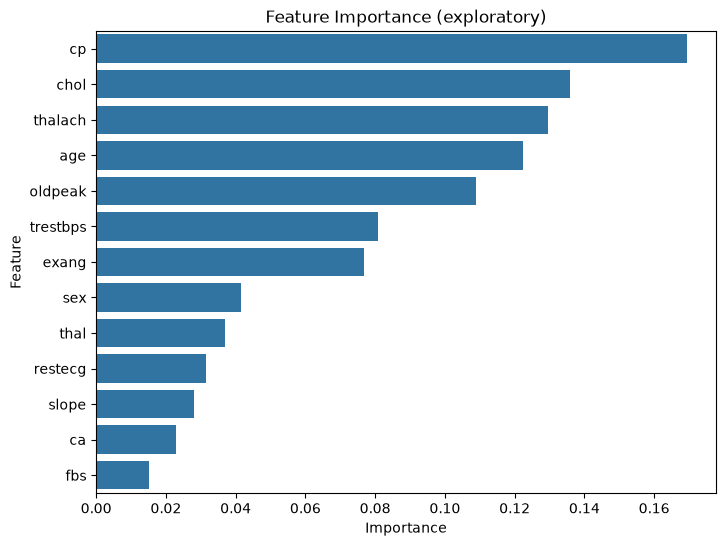

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance (exploratory)")
plt.show()

## 9. Save the Preprocessing Pipeline

Here we save the *entire* `ColumnTransformer` (imputer + scaler bundled together) as a single
artifact, plus the IQR bounds, so inference on brand-new data is fully reproducible.

In [11]:
import joblib

joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(iqr_bounds, "../models/iqr_bounds.pkl")

print("Saved preprocessor.pkl and iqr_bounds.pkl")

Saved preprocessor.pkl and iqr_bounds.pkl
